In [1]:
"""
Loan default prediction for credit risk management: data preparation,
Logistic Regression as an interpretable benchmark and Gradient Boosting
as the challenger model, compared on train, validation and test partitions.
"""

# Libraries
# =========
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Configuration
# =============
DATA_DIR = "data"
DATA_PATH = os.path.join(DATA_DIR, "Loan_Default.csv")

TARGET = "Status"

# ID is only an identifier, year is constant and the other three variables
# have one category covering more than 99.5% of the observations
DROP_COLS = ["ID", "year", "open_credit", "construction_type", "Security_Type"]

# Variables whose missing pattern or whose categories identify the target
# almost perfectly (see the leakage check below)
LEAKY_COLS = ["rate_of_interest", "Interest_rate_spread", "Upfront_charges",
              "LTV", "property_value", "dtir1", "credit_type"]

TRAIN_SIZE, VALID_SIZE, TEST_SIZE = 0.6, 0.3, 0.1
LIFT_DEPTHS = [0.05, 0.10, 0.20]
SEED = 123

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

Observations: 148670 | Variables: 34

Target distribution
Status
0    0.7536
1    0.2464
Name: proportion, dtype: float64


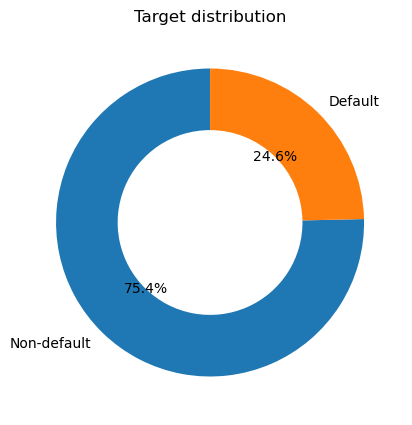

In [2]:
# Load data
# =========
df = pd.read_csv(DATA_PATH)

print("Observations:", len(df), "| Variables:", df.shape[1])
print("\nTarget distribution")
print(df[TARGET].value_counts(normalize=True).round(4))

plt.figure(figsize=(5, 5))
plt.pie(df[TARGET].value_counts().sort_index(), labels=["Non-default", "Default"],
        autopct="%1.1f%%", wedgeprops={"width": 0.4}, startangle=90)
plt.title("Target distribution")
plt.show()

In [3]:
# Leakage check
# =============
# Some inputs are missing almost only for defaulted loans, and some categories
# contain only defaults: in both cases the input already reveals the target
print("\nDefault rate when the value is missing")
for col in df.columns[df.isna().any()]:
    rate = df.loc[df[col].isna(), TARGET].mean()
    if rate > 0.5:
        print(f"{col:22s} missing: {int(df[col].isna().sum()):6d} | default rate: {rate:.3f}")

print("\nCategories made almost entirely of defaults")
for col in df.select_dtypes(exclude="number").columns:
    rates = df.groupby(col)[TARGET].agg(["mean", "size"])
    for category, row in rates[rates["mean"] > 0.95].iterrows():
        print(f"{col:22s} {category:10s} | size: {int(row['size']):6d} | default rate: {row['mean']:.3f}")


Default rate when the value is missing
rate_of_interest       missing:  36439 | default rate: 1.000
Interest_rate_spread   missing:  36639 | default rate: 1.000
Upfront_charges        missing:  39642 | default rate: 0.920
property_value         missing:  15098 | default rate: 1.000
age                    missing:    200 | default rate: 1.000
submission_of_application missing:    200 | default rate: 1.000
LTV                    missing:  15098 | default rate: 1.000
dtir1                  missing:  24121 | default rate: 0.676

Categories made almost entirely of defaults
construction_type      mh         | size:     33 | default rate: 1.000
Secured_by             land       | size:     33 | default rate: 1.000
credit_type            EQUI       | size:  15298 | default rate: 1.000
Security_Type          Indriect   | size:     33 | default rate: 1.000


In [4]:
# Data preparation
# ================
data = df.drop(columns=DROP_COLS)

y = data[TARGET]
X = data.drop(columns=TARGET)

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Numerical inputs are stored as floats, which partial dependence requires
X[num_cols] = X[num_cols].astype(float)

print("\nNumerical inputs:", len(num_cols), "| Categorical inputs:", len(cat_cols))

# Stratified split into 60% training, 30% validation and 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=TRAIN_SIZE, stratify=y, random_state=SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, train_size=VALID_SIZE / (VALID_SIZE + TEST_SIZE),
    stratify=y_temp, random_state=SEED
)

print("Train:", len(X_train), "| Validation:", len(X_valid), "| Test:", len(X_test))


def build_preprocessor(numeric, categorical):
    # Numerical inputs are imputed by median, categorical ones by the most
    # frequent category, exactly as in the SAS imputation node
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])


def build_models(numeric, categorical):
    logistic = Pipeline([
        ("prep", build_preprocessor(numeric, categorical)),
        ("scale", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])

    boosting = Pipeline([
        ("prep", build_preprocessor(numeric, categorical)),
        # Early stopping holds out part of the training data, so the validation
        # partition stays free for model selection and for the cutoff
        ("model", HistGradientBoostingClassifier(early_stopping=True, random_state=SEED)),
    ])

    return {"Logistic Regression": logistic, "Gradient Boosting": boosting}


Numerical inputs: 10 | Categorical inputs: 18
Train: 89202 | Validation: 44600 | Test: 14868


In [5]:
# Evaluation metrics
# ==================
def ks_statistic(y_true, scores):
    # Maximum distance between the cumulative distributions of the two classes
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    k = int(np.argmax(tpr - fpr))
    return tpr[k] - fpr[k], thresholds[k]


def cumulative_lift(y_true, scores, depth):
    # Default rate among the riskiest applicants divided by the overall rate
    n = int(len(scores) * depth)
    top = np.argsort(scores)[::-1][:n]
    return y_true.iloc[top].mean() / y_true.mean()


def evaluate(y_true, scores, threshold=0.5):
    predicted = (scores >= threshold).astype(int)
    ks, cutoff = ks_statistic(y_true, scores)

    metrics = {
        "accuracy": accuracy_score(y_true, predicted),
        "auc": roc_auc_score(y_true, scores),
        "f1": f1_score(y_true, predicted),
        "ks": ks,
        "ks_cutoff": cutoff,
    }
    for depth in LIFT_DEPTHS:
        metrics[f"lift_{int(depth * 100)}%"] = cumulative_lift(y_true, scores, depth)

    return metrics


def fit_and_score(models, numeric, categorical):
    scores, results = {}, []

    for name, model in models.items():
        model.fit(X_train[numeric + categorical], y_train)

        scores[name] = {
            "TRAIN": (y_train, model.predict_proba(X_train[numeric + categorical])[:, 1]),
            "VALIDATE": (y_valid, model.predict_proba(X_valid[numeric + categorical])[:, 1]),
            "TEST": (y_test, model.predict_proba(X_test[numeric + categorical])[:, 1]),
        }

        for partition, (target, probability) in scores[name].items():
            results.append({"model": name, "partition": partition, **evaluate(target, probability)})

    return scores, pd.DataFrame(results).set_index(["model", "partition"])


Performance without the contaminated variables
                               accuracy     auc      f1      ks  ks_cutoff  lift_5%  lift_10%  lift_20%
model               partition                                                                          
Logistic Regression TRAIN        0.7848  0.7390  0.3667  0.3625     0.2603   3.0670    2.6580    2.1974
                    VALIDATE     0.7829  0.7333  0.3627  0.3456     0.2490   3.0131    2.6119    2.1602
                    TEST         0.7840  0.7301  0.3662  0.3521     0.2490   3.1676    2.6352    2.1443
Gradient Boosting   TRAIN        0.8191  0.8091  0.5089  0.4669     0.2460   3.7830    3.3058    2.6087
                    VALIDATE     0.8114  0.7919  0.4898  0.4326     0.2644   3.6499    3.1951    2.5041
                    TEST         0.8121  0.7882  0.4879  0.4300     0.2763   3.7083    3.2004    2.4950


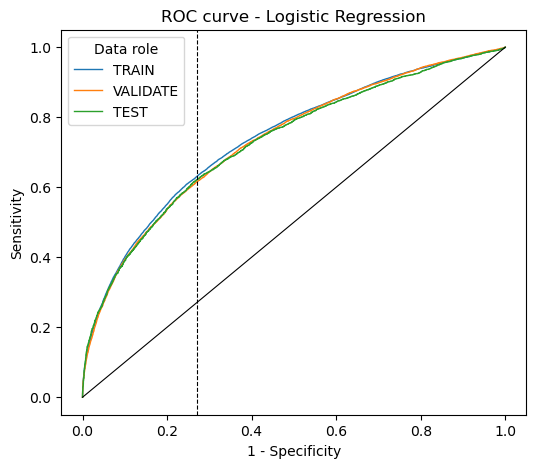

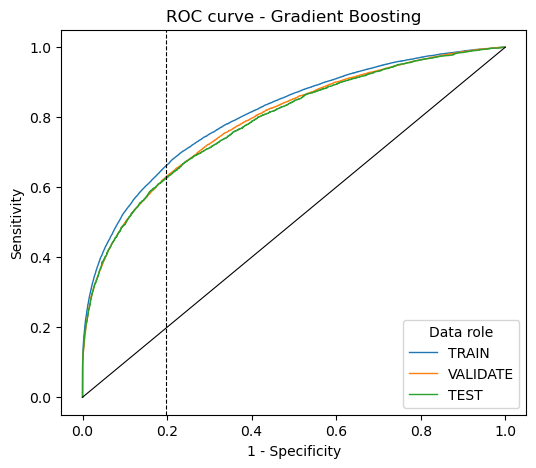

In [6]:
# Models without the contaminated variables
# =========================================
clean_num = [c for c in num_cols if c not in LEAKY_COLS]
clean_cat = [c for c in cat_cols if c not in LEAKY_COLS]

models = build_models(clean_num, clean_cat)
scores, performance = fit_and_score(models, clean_num, clean_cat)

print("\nPerformance without the contaminated variables")
print(performance.round(4))

for name in models:
    plt.figure(figsize=(6, 5))
    for partition, (target, probability) in scores[name].items():
        fpr, tpr, _ = roc_curve(target, probability)
        plt.plot(fpr, tpr, linewidth=1, label=partition)

    # Vertical line at the point of maximum separation on the validation set
    fpr, tpr, _ = roc_curve(*scores[name]["VALIDATE"])
    plt.axvline(fpr[np.argmax(tpr - fpr)], color="black", linewidth=0.8, linestyle="--")

    plt.plot([0, 1], [0, 1], color="black", linewidth=0.8)
    plt.xlabel("1 - Specificity")
    plt.ylabel("Sensitivity")
    plt.title(f"ROC curve - {name}")
    plt.legend(title="Data role")
    plt.show()


Champion model: Gradient Boosting

Confusion matrix on test at default cutoff (0.500)
predicted      0     1
actual                
0          10743   461
1           2333  1331
Accuracy: 0.8121 | F1: 0.4879

Confusion matrix on test at KS cutoff from validation (0.264)
predicted     0     1
actual               
0          9016  2188
1          1377  2287
Accuracy: 0.7602 | F1: 0.562


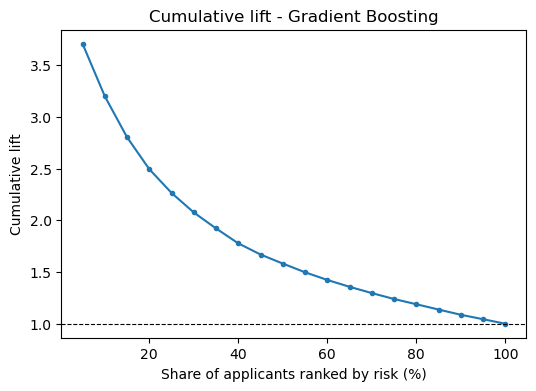

In [7]:
# Champion model: confusion matrix and lift
# =========================================
# The champion is chosen on the validation partition and the operating cutoff
# is estimated there as well: the test set is used only for the final assessment
champion_name = performance.xs("VALIDATE", level="partition")["auc"].idxmax()
champion = models[champion_name]
y_true, y_score = scores[champion_name]["TEST"]

print("\nChampion model:", champion_name)

_, ks_cutoff = ks_statistic(*scores[champion_name]["VALIDATE"])

for threshold, label in [(0.5, "default cutoff"), (ks_cutoff, "KS cutoff from validation")]:
    predicted = (y_score >= threshold).astype(int)
    matrix = pd.crosstab(y_true, predicted, rownames=["actual"], colnames=["predicted"])
    print(f"\nConfusion matrix on test at {label} ({threshold:.3f})")
    print(matrix)
    print("Accuracy:", round(accuracy_score(y_true, predicted), 4),
          "| F1:", round(f1_score(y_true, predicted), 4))

order = np.argsort(y_score)[::-1]
depths = np.arange(0.05, 1.01, 0.05)
lift_curve = [y_true.iloc[order[:int(len(y_score) * d)]].mean() / y_true.mean() for d in depths]

plt.figure(figsize=(6, 4))
plt.plot(depths * 100, lift_curve, marker="o", markersize=3)
plt.axhline(1.0, linestyle="--", color="black", linewidth=0.8)
plt.xlabel("Share of applicants ranked by risk (%)")
plt.ylabel("Cumulative lift")
plt.title(f"Cumulative lift - {champion_name}")
plt.show()

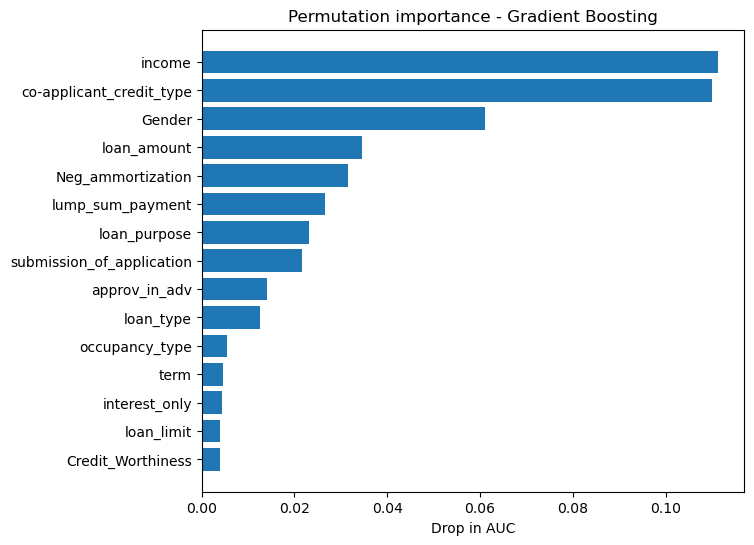


Most important inputs: ['Neg_ammortization', 'loan_amount', 'Gender', 'co-applicant_credit_type', 'income']


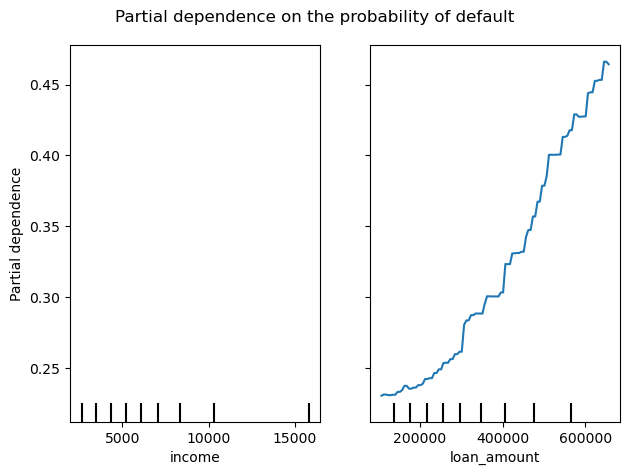


Logistic regression: strongest effects on the log-odds of default
num__income                         -0.388
cat__Gender_Joint                   -0.381
cat__co-applicant_credit_type_CIB   -0.364
cat__lump_sum_payment_not_lpsm      -0.186
cat__Neg_ammortization_not_neg      -0.161
cat__Gender_Female                   0.164
cat__Neg_ammortization_neg_amm       0.169
cat__lump_sum_payment_lpsm           0.202
cat__Gender_Male                     0.254
cat__co-applicant_credit_type_EXP    0.369
dtype: float64


In [8]:
# Variable importance and effects
# ===============================
# Permutation importance is computed on a sample of the test set to keep
# the computation fast, and measures the drop in AUC when a column is shuffled
sample = X_test[clean_num + clean_cat].sample(5000, random_state=SEED)
sample_y = y_test.loc[sample.index]

importance = permutation_importance(champion, sample, sample_y, scoring="roc_auc",
                                    n_repeats=5, random_state=SEED)

importance = pd.Series(importance.importances_mean, index=sample.columns).sort_values()

plt.figure(figsize=(7, 6))
plt.barh(importance.index[-15:], importance.values[-15:])
plt.xlabel("Drop in AUC")
plt.title(f"Permutation importance - {champion_name}")
plt.show()

# Partial dependence is shown for the two most important numerical inputs,
# because the plot is not defined for categorical ones
top_features = [c for c in importance.index[::-1] if c in clean_num][:2]
print("\nMost important inputs:", importance.index[-5:].tolist())

PartialDependenceDisplay.from_estimator(champion, sample, top_features)
plt.suptitle("Partial dependence on the probability of default")
plt.tight_layout()
plt.show()

coefficients = pd.Series(
    models["Logistic Regression"].named_steps["model"].coef_[0],
    index=models["Logistic Regression"].named_steps["prep"].get_feature_names_out(),
).sort_values()

print("\nLogistic regression: strongest effects on the log-odds of default")
print(pd.concat([coefficients.head(5), coefficients.tail(5)]).round(3))

In [9]:
# Comparison with the full set of variables
# =========================================
# Refitting on every input shows the size of the problem: the boosting reaches
# an almost perfect AUC by learning the missing pattern, not the credit risk
full_models = build_models(num_cols, cat_cols)
_, full_performance = fit_and_score(full_models, num_cols, cat_cols)

comparison = pd.concat([
    performance.xs("TEST", level="partition")[["accuracy", "auc", "f1", "ks"]].add_suffix("_clean"),
    full_performance.xs("TEST", level="partition")[["accuracy", "auc", "f1", "ks"]].add_suffix("_full"),
], axis=1)

print("\nTest performance: clean inputs versus all inputs")
print(comparison.round(4))


Test performance: clean inputs versus all inputs
                     accuracy_clean  auc_clean  f1_clean  ks_clean  accuracy_full  auc_full  f1_full  ks_full
model                                                                                                        
Logistic Regression          0.7840     0.7301    0.3662    0.3521         0.8715    0.8634   0.6677   0.5902
Gradient Boosting            0.8121     0.7882    0.4879    0.4300         1.0000    1.0000   1.0000   1.0000
